In [6]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.


In [84]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report, confusion_matrix

In [85]:
DATA_DIR = '../../data/churn'

features = pd.read_csv(f'{DATA_DIR}/ecommerce_customer_features.csv')
targets = pd.read_csv(f'{DATA_DIR}/ecommerce_customer_targets.csv')

df = features.merge(targets, on='Customer_ID')
df['churned'] = df['churned'].map({'Yes': 1, 'No': 0})

df.head()

,Customer_ID,account_age_months,avg_order_value,total_orders,days_since_last_purchase,discount_usage_rate,return_rate,customer_support_tickets,loyalty_member,browsing_frequency_per_week,cart_abandonment_rate,product_review_score_avg,engagement_score,satisfaction_score,price_sensitivity_index,churned
0,0520df14-712d-4c69-a0c5-95a2e7dfc1ff,46,164.96,12,17,0.243,0.1720,0,No,6.1,0.430,5.00,6.58,9.43,3.7,0
1,a4013b3f-0688-4096-a194-6074be8ffec8,3,39.09,4,5,0.591,0.0808,1,No,4.1,0.183,4.44,6.25,8.50,6.9,0
2,eb870f2c-ed3d-4a21-a8ac-273fae69ea4f,29,37.42,8,47,0.212,0.1424,0,No,1.2,0.426,3.87,3.32,8.40,4.3,0
3,a7433451-8ea9-428a-9d80-679c6963b39f,35,62.64,9,3,0.699,0.0128,0,No,3.8,0.730,4.75,6.42,9.71,7.5,0
4,43f81935-49e3-44d3-94d1-5c4715738988,39,113.03,1,7,0.382,0.0232,0,No,5.4,0.613,5.00,6.48,9.92,5.0,0


In [86]:
FEATURES = [
    'account_age_months',
    'avg_order_value',
    'total_orders',
    'days_since_last_purchase',
    'discount_usage_rate',
    'return_rate',
    'browsing_frequency_per_week',
    'cart_abandonment_rate',
]
TARGET = 'churned'

x = df[FEATURES]
y = df[TARGET]

print(x.shape)
print(y.value_counts(normalize=True))

(6000, 8)
churned
0    0.845167
1    0.154833
Name: proportion, dtype: float64


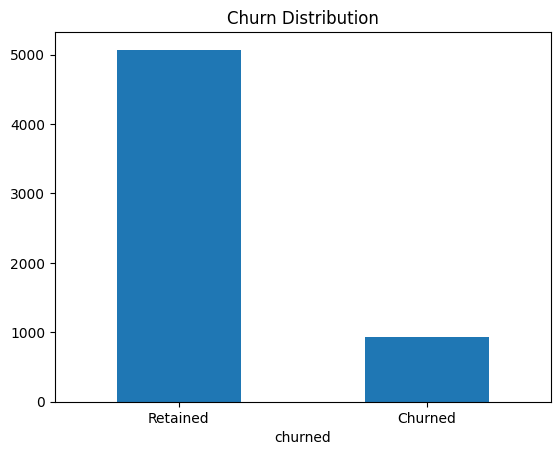

In [87]:
# 클래스 불균형 확인
y.value_counts().plot(kind='bar', title='Churn Distribution')
plt.xticks([0, 1], ['Retained', 'Churned'], rotation=0)
plt.show()

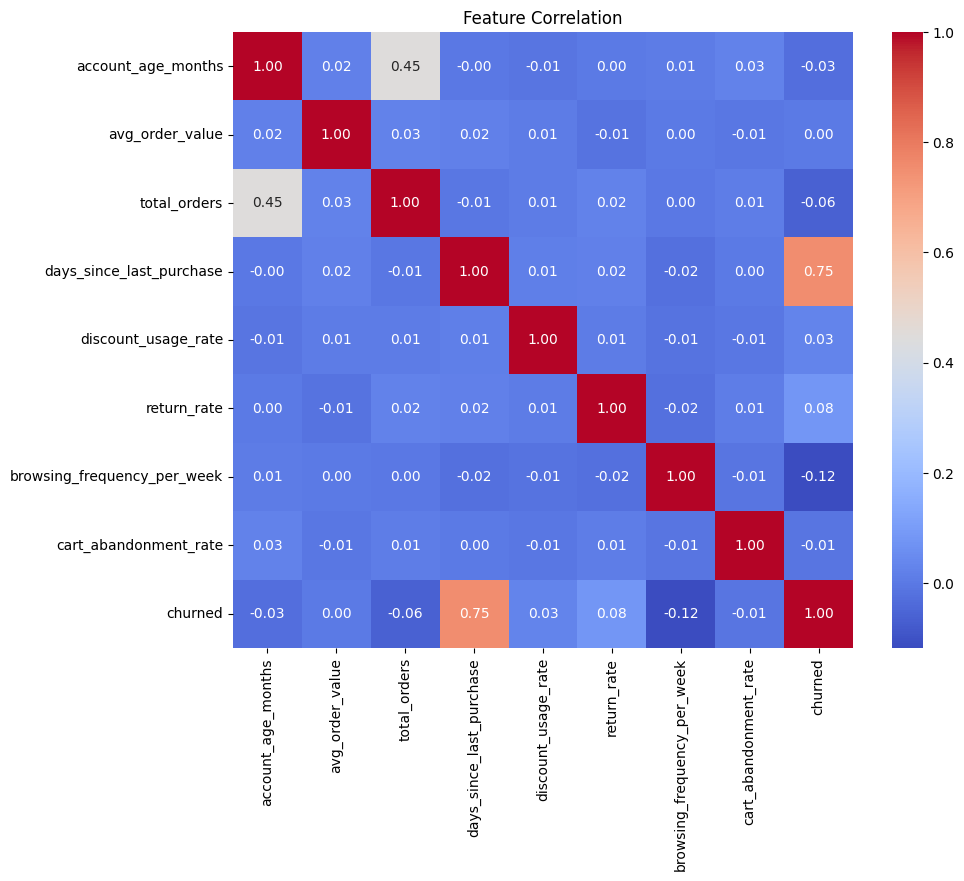

In [88]:
# 피처 상관관계 시각화
plt.figure(figsize=(10, 8))
sns.heatmap(df[FEATURES + [TARGET]].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Feature Correlation')
plt.show()

In [89]:
train_ratio, val_ratio, test_ratio = 0.7, 0.15, 0.15

x_train, x_remaining, y_train, y_remaining = train_test_split(
    x, y, test_size=1 - train_ratio, random_state=42, stratify=y
)
x_valid, x_test, y_valid, y_test = train_test_split(
    x_remaining, y_remaining, test_size=test_ratio / (val_ratio + test_ratio), random_state=42, stratify=y_remaining # 클래스 분포 균등하게
)

# 정규화
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_valid_scaled = scaler.transform(x_valid)
x_test_scaled = scaler.transform(x_test)

print(f'Train: {x_train.shape}, Valid: {x_valid.shape}, Test: {x_test.shape}')

Train: (4199, 8), Valid: (900, 8), Test: (901, 8)


In [90]:
# 로지스틱 회귀 이용
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(x_train_scaled, y_train)
lr_pred = lr.predict(x_test_scaled)
lr_proba = lr.predict_proba(x_test_scaled)[:, 1]

print('--- 로지스틱 회귀 ---')
print(f'정확도 : {accuracy_score(y_test, lr_pred):.4f}')
print(f'F1 점수 : {f1_score(y_test, lr_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, lr_proba):.4f}')

--- 로지스틱 회귀 ---
정확도 : 0.9634
F1 점수 : 0.8800
ROC-AUC  : 0.9917


In [91]:
# Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train_scaled, y_train)
rf_pred = rf.predict(x_test_scaled)
rf_proba = rf.predict_proba(x_test_scaled)[:, 1]

print('--- Random Forest ---')
print(f'정확도 : {accuracy_score(y_test, rf_pred):.4f}')
print(f'F1 점수 : {f1_score(y_test, rf_pred):.4f}')
print(f'ROC-AUC  : {roc_auc_score(y_test, rf_proba):.4f}')

--- Random Forest ---
정확도 : 0.9578
F1 점수 : 0.8582
ROC-AUC  : 0.9886


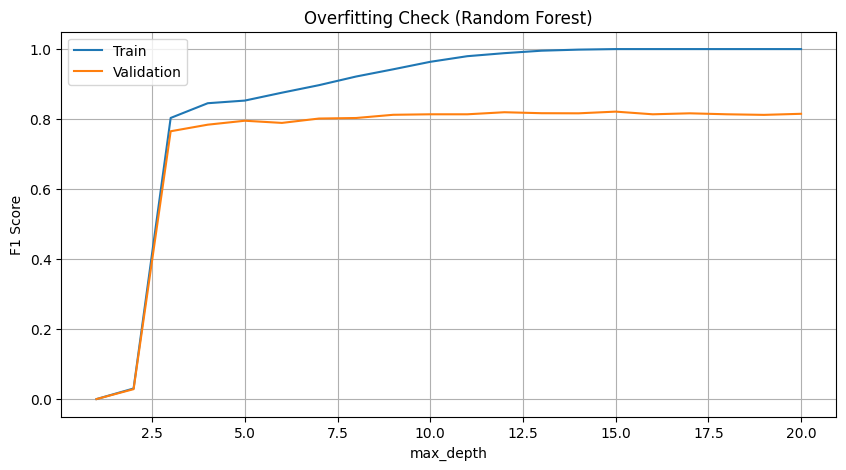

In [92]:
train_scores = []
valid_scores = []
max_depth_range = range(1, 21)

for depth in max_depth_range:
    model = RandomForestClassifier(n_estimators=100, max_depth=depth, random_state=42)
    model.fit(x_train, y_train)
    train_scores.append(f1_score(y_train, model.predict(x_train)))
    valid_scores.append(f1_score(y_valid, model.predict(x_valid)))

plt.figure(figsize=(10, 5))
plt.plot(max_depth_range, train_scores, label='Train')
plt.plot(max_depth_range, valid_scores, label='Validation')
plt.xlabel('max_depth')
plt.ylabel('F1 Score')
plt.title('Overfitting Check (Random Forest)')
plt.legend()
plt.grid(True)
plt.show()

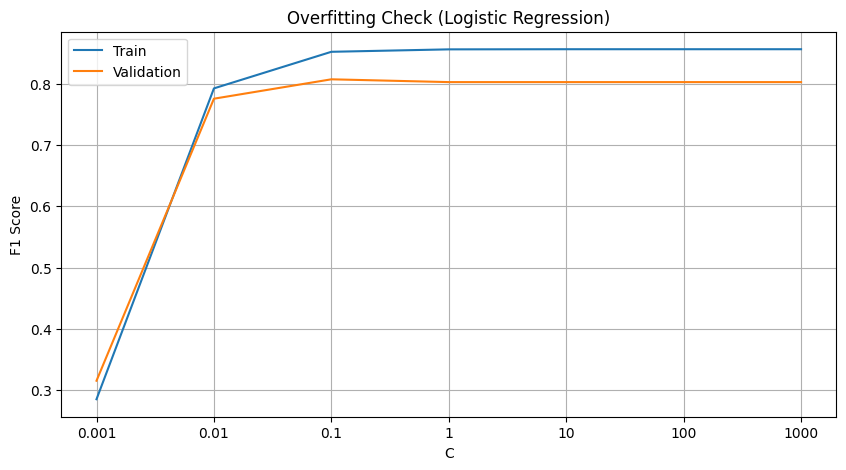

In [93]:
train_scores_lr = []
valid_scores_lr = []
c_range = [0.001, 0.01, 0.1, 1, 10, 100, 1000]

for c in c_range:
    model = LogisticRegression(C=c, random_state=42, max_iter=1000)
    model.fit(x_train_scaled, y_train)
    train_scores_lr.append(f1_score(y_train, model.predict(x_train_scaled)))
    valid_scores_lr.append(f1_score(y_valid, model.predict(x_valid_scaled)))

plt.figure(figsize=(10, 5))
plt.plot(range(len(c_range)), train_scores_lr, label='Train')
plt.plot(range(len(c_range)), valid_scores_lr, label='Validation')
plt.xticks(range(len(c_range)), [str(c) for c in c_range])
plt.xlabel('C')
plt.ylabel('F1 Score')
plt.title('Overfitting Check (Logistic Regression)')
plt.legend()
plt.grid(True)
plt.show()

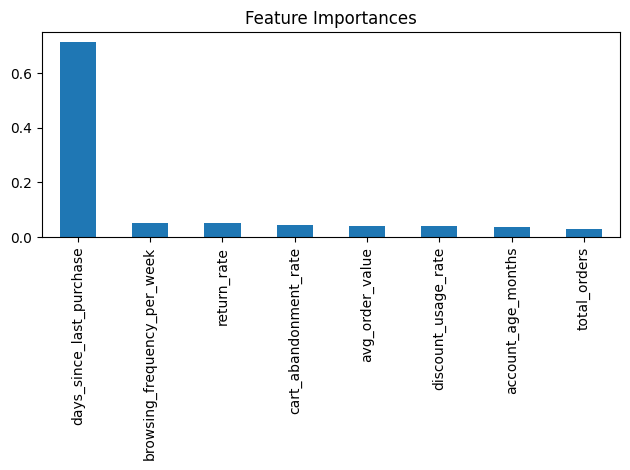

In [94]:
# 피처 중요도 (Random Forest)
importances = pd.Series(rf.feature_importances_, index=FEATURES).sort_values(ascending=False)
importances.plot(kind='bar', title='Feature Importances')
plt.tight_layout()
plt.show()